# Tech Challenge — Etapa 2
## Modelagem com Redes Neurais (MLP)

Nesta etapa será construída uma rede neural do tipo MLP utilizando PyTorch para previsão de churn.

Serão realizadas:

- definição da arquitetura da rede
- treinamento com batching
- early stopping
- avaliação com múltiplas métricas
- comparação com modelos baseline
- rastreamento de experimentos com MLflow

In [1]:
# Manipulação de dados
import os 
import joblib 
import pandas as pd
import numpy as np
import random

# Visualização
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve
)

# Deep Learning
import torch

# https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html
# What is torch.nn really?
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import seaborn as sns

# Experiment tracking
import mlflow
import mlflow.pytorch
import mlflow.sklearn

# Fixar seeds para reprodutibilidade 
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
# Carregar o dataset
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

print("Dataset original:", df.shape)

df.head()


Dataset original: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Limpar dataset (missing values etapa 4.1 e N/A TotalCharges etapa 4.3 do EDA)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna(subset=["TotalCharges"])

# converter target
df["Churn"] = df["Churn"].str.strip().map({"Yes": 1, "No": 0})

# remover identificador
df_model = df.drop(columns=["customerID"])

print("Dataset após limpeza:", df_model.shape)

# salvar dataset tratado
df_model.to_csv("../data/processed/telco_clean.csv", index=False)

df_model.head()


Dataset após limpeza: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Preparação dos dados para modelagem

Nesta etapa carregamos o dataset limpo salvo em `data/processed`
e preparamos os dados para treinamento dos modelos.

In [4]:
df = pd.read_csv("../data/processed/telco_clean.csv")

print("Dataset carregado:", df.shape)

df.head()

Dataset carregado: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Separação de features e variável alvo

Nesta etapa separamos as variáveis explicativas (features) da variável alvo (Churn).

In [5]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (7032, 19)
Shape y: (7032,)


## Distribuição da variável alvo

Antes de treinar modelos de classificação, é importante verificar o balanceamento
da variável alvo.

In [6]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


## Distribuição da variável alvo

Antes do treinamento dos modelos, é importante verificar o balanceamento da variável alvo.

Observa-se que aproximadamente 73% dos clientes não cancelaram o serviço, enquanto cerca de 27% cancelaram (churn). Esse leve desbalanceamento será considerado na avaliação dos modelos.

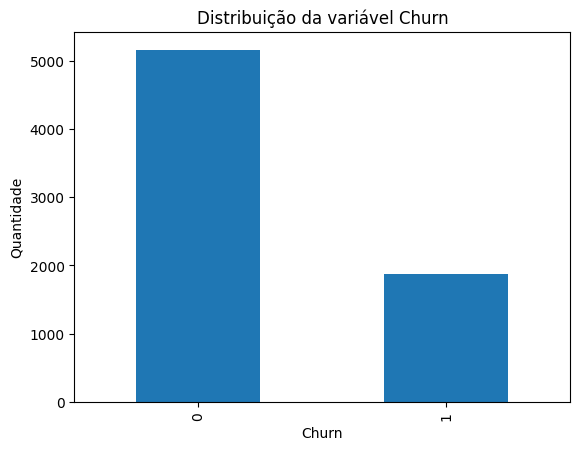

In [7]:
y.value_counts().plot(kind="bar")
plt.title("Distribuição da variável Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade")
plt.show()

## Divisão em conjunto de treino e teste

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (5625, 19)
Test shape: (1407, 19)


## Codificação das variáveis categóricas

Aplicamos One-Hot Encoding nas variáveis categóricas (transformando-as em variáveis numéricas) após a divisão
entre treino e teste para evitar data leakage.

In [9]:
# tira a primeira categoria para evitar multicolinearidade
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# alinhar colunas do teste com treino
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Train features:", X_train.shape)
print("Test features:", X_test.shape)

print(X_train.columns)

Train features: (5625, 30)
Test features: (1407, 30)
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


## Separação de conjunto de validação

Para aplicar early stopping de forma adequada, o conjunto de treino foi
subdividido em treino e validação.

In [10]:
X_train_full = X_train
y_train_full = y_train

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (4500, 30)
Validation: (1125, 30)
Test: (1407, 30)


## Escalonamento das variáveis

Aplicamos normalização utilizando StandardScaler para garantir que todas
as variáveis estejam na mesma escala. Esse passo é importante para
modelos baseados em redes neurais.

In [11]:
scaler = StandardScaler()

# Usamos fit_transform no treino e transform no teste para evitar data leakage, pois o modelo aprende a escala no teste

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4500, 30)
Validation: (1125, 30)
Test: (1407, 30)


## Conversão dos dados para tensores PyTorch

Para utilizar redes neurais com PyTorch, os dados precisam ser convertidos
para tensores.

In [12]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print("Tensor X_train:", X_train_tensor.shape)
print("Tensor X_val:", X_val_tensor.shape)
print("Tensor X_test:", X_test_tensor.shape)

Tensor X_train: torch.Size([4500, 30])
Tensor X_val: torch.Size([1125, 30])
Tensor X_test: torch.Size([1407, 30])


## Criação do DataLoader

Utilizamos DataLoader para dividir os dados em batches durante o
treinamento da rede neural.

In [13]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Batches treino:", len(train_loader))
print("Batches validação:", len(val_loader))

Batches treino: 141
Batches validação: 36


## Definição da arquitetura da rede neural

Foi utilizada uma rede neural do tipo MLP (MultiLayer Perceptron)
com duas camadas ocultas e função de ativação ReLU - Unidade Linear Retificada.
f(x) = max(0,x) >> transforma valores negativos em zero e mantém os positivos, introduzindo não linearidade, acelerando o treinamento e atenuando o problema do desaparecimento do gradiente

Fonte: https://builtin.com/machine-learning/relu-activation-function

In [14]:
class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)

        )

    def forward(self, x):

        return self.model(x)

In [15]:
input_dim = X_train_tensor.shape[1]

model = MLP(input_dim)

print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Configuração da função de perda e otimizador

Utilizamos BCEWithLogitsLoss para classificação binária e o
otimizador Adam para atualização dos pesos da rede.

https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

In [16]:
# Para medir o erro e otimizar o modelo, usamos a função de perda (loss function) e o otimizador (optimizer)
# Calcula quão errado o modelo está.
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Treinamento da rede neural (MLP)

Nesta etapa realizamos o treinamento da rede neural utilizando os dados
de treino organizados em mini-batches por meio do DataLoader.

O processo de treinamento consiste em:

1. Propagação direta (forward pass)
2. Cálculo da função de perda (loss)
3. Retropropagação do erro (backpropagation)
4. Atualização dos pesos da rede (optimizer)

Também utilizamos **early stopping**, monitorando a perda no conjunto
de validação para evitar overfitting.

### Definição dos parâmetros de treinamento

Definimos o número máximo de épocas de treinamento e o parâmetro
de **early stopping**, que interrompe o treinamento caso a perda
de validação pare de melhorar por um determinado número de épocas.

In [17]:
epochs = 100
patience = 10

best_val_loss = float("inf")
counter = 0

train_losses = []
val_losses = []

### Loop de treinamento da rede

Durante cada época, o modelo percorre todos os batches do conjunto
de treino realizando a atualização dos pesos da rede.

Após cada época também avaliamos a perda no conjunto de validação,
permitindo monitorar o desempenho do modelo em dados não vistos.

In [18]:
for epoch in range(epochs):

    # ======================
    # Treinamento
    # ======================
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # ======================
    # Validação
    # ======================
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    # ======================
    # Early stopping
    # ======================
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        counter = 0

        torch.save(model.state_dict(), "../models/mlp_churn_best.pt")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping acionado")
        break

Epoch 001 | Train Loss: 0.5435 | Val Loss: 0.4631
Epoch 002 | Train Loss: 0.4320 | Val Loss: 0.4430
Epoch 003 | Train Loss: 0.4189 | Val Loss: 0.4442
Epoch 004 | Train Loss: 0.4128 | Val Loss: 0.4347
Epoch 005 | Train Loss: 0.4075 | Val Loss: 0.4348
Epoch 006 | Train Loss: 0.4043 | Val Loss: 0.4329
Epoch 007 | Train Loss: 0.4011 | Val Loss: 0.4353
Epoch 008 | Train Loss: 0.3980 | Val Loss: 0.4323
Epoch 009 | Train Loss: 0.3966 | Val Loss: 0.4375
Epoch 010 | Train Loss: 0.3954 | Val Loss: 0.4366
Epoch 011 | Train Loss: 0.3937 | Val Loss: 0.4357
Epoch 012 | Train Loss: 0.3930 | Val Loss: 0.4369
Epoch 013 | Train Loss: 0.3907 | Val Loss: 0.4362
Epoch 014 | Train Loss: 0.3882 | Val Loss: 0.4417
Epoch 015 | Train Loss: 0.3897 | Val Loss: 0.4369
Epoch 016 | Train Loss: 0.3864 | Val Loss: 0.4390
Epoch 017 | Train Loss: 0.3861 | Val Loss: 0.4381
Epoch 018 | Train Loss: 0.3836 | Val Loss: 0.4370
Early stopping acionado


### Carregamento do melhor modelo

Após o treinamento, carregamos os pesos do modelo que apresentou
a menor perda no conjunto de validação.

In [19]:
model.load_state_dict(torch.load("../models/mlp_churn_best.pt"))
model.eval()

MLP(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

### Curvas de treinamento

A visualização das curvas de perda (loss) permite acompanhar
a evolução do treinamento e verificar possíveis sinais de
overfitting ou underfitting.

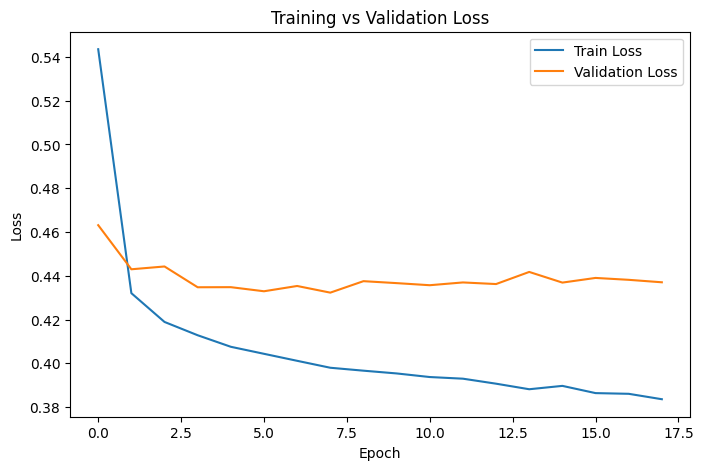

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

### Curvas de perda durante o treinamento

O gráfico acima apresenta a evolução da função de perda (*loss*) ao longo das épocas de treinamento da rede neural.

Foram registradas duas curvas:

- **Train Loss**: perda calculada sobre o conjunto de treinamento.
- **Validation Loss**: perda calculada sobre o conjunto de validação.

A análise dessas curvas permite acompanhar o processo de aprendizado do modelo. 
Em um treinamento adequado, espera-se que ambas as perdas diminuam gradualmente à medida que o modelo aprende padrões nos dados.

A comparação entre as duas curvas também permite identificar possíveis problemas de **overfitting** ou **underfitting**:

- **Overfitting** ocorre quando a perda de treino continua diminuindo enquanto a perda de validação começa a aumentar, indicando que o modelo está se ajustando excessivamente aos dados de treinamento.
- **Underfitting** ocorre quando ambas as perdas permanecem altas, indicando que o modelo não conseguiu aprender padrões relevantes nos dados.

Neste trabalho, o conjunto de validação foi utilizado para monitorar o desempenho do modelo durante o treinamento e aplicar **early stopping**, interrompendo o treinamento quando a perda de validação deixa de melhorar.

## Avaliação do modelo no conjunto de teste

Após o treinamento da rede neural, avaliamos o desempenho do modelo
no conjunto de teste, que contém dados não utilizados durante o treinamento.

O objetivo dessa etapa é medir a capacidade de generalização do modelo,
ou seja, sua habilidade de realizar previsões corretas em novos dados.

Para isso, utilizamos as seguintes métricas de classificação:

- **Accuracy**: proporção de previsões corretas.
- **Precision**: proporção de previsões positivas corretas.
- **Recall**: capacidade do modelo de identificar corretamente os casos positivos.
- **F1-score**: média harmônica entre precisão e recall.
- **ROC-AUC**: mede a capacidade do modelo de distinguir entre as classes.

Além disso, utilizamos a **matriz de confusão** para visualizar os
acertos e erros de classificação.

### Geração das previsões e Cálculo das métricas de desempenho

In [21]:
# desativar gradientes
model.eval()

with torch.no_grad():

    logits = model(X_test_tensor).squeeze()

    probs = torch.sigmoid(logits)
    y_prob_mlp = probs.numpy()

    #y_pred = (probs >= 0.5).int().numpy()
    '''
    Accuracy: 0.7960199004975125
    Precision: 0.638095238095238
    Recall: 0.5374331550802139
    F1-score: 0.5834542815674891
    ROC-AUC: 0.8339644667160185
    '''
    threshold = 0.30
    y_pred = (probs >= threshold).int().numpy()
    ''''
    Accuracy: 0.7526652452025586
    Precision: 0.524904214559387
    Recall: 0.732620320855615
    F1-score: 0.6116071428571429
    ROC-AUC: 0.8339644667160185
    '''

y_true = y_test.values

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_mlp = roc_auc_score(y_true, y_prob_mlp)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_mlp)

Accuracy: 0.7526652452025586
Precision: 0.524904214559387
Recall: 0.732620320855615
F1-score: 0.6116071428571429
ROC-AUC: 0.8339644667160185


### Ajuste do limiar de decisão (threshold)

Por padrão, modelos de classificação binária utilizam um threshold de 0.5
para converter probabilidades em classes.

Entretanto, em problemas de churn, pode ser interessante reduzir esse limiar
para aumentar a capacidade do modelo de identificar clientes que possuem
risco de cancelamento.

Ao reduzir o threshold para **0.30**, observamos as seguintes mudanças:

| Métrica | Threshold 0.5 | Threshold 0.3 |
|--------|---------------|---------------|
| Accuracy | 0.80 | 0.75 |
| Precision | 0.64 | 0.52 |
| Recall | 0.54 | 0.73 |
| F1-score | 0.58 | 0.61 |

Observa-se que a redução do threshold aumenta significativamente o **recall**,
permitindo identificar uma maior proporção de clientes que realmente cancelam
o serviço.

Por outro lado, ocorre uma redução na **precision**, indicando um aumento
nos falsos positivos.

Esse comportamento é esperado em problemas de churn, contudo, neste contexto, entendemos ser melhor identificar mais clientes em risco (maior recall), pois perder um cliente provavelmente é mais custoso do que oferecer
um incentivo desnecessário.

### Curva Precision-Recall

A curva Precision-Recall mostra o comportamento da precisão e do recall
para diferentes valores de threshold.

Essa visualização permite entender melhor o trade-off entre identificar
clientes que irão cancelar (recall) e evitar classificações incorretas
(precision).

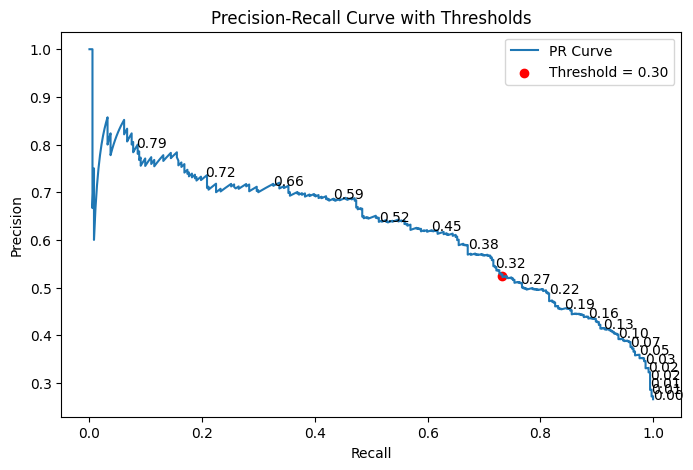

In [22]:
precision, recall, thresholds = precision_recall_curve(y_true, probs.numpy())

plt.figure(figsize=(8,5))

plt.plot(recall, precision, label="PR Curve")

# marcar alguns thresholds
for i in range(0, len(thresholds), 65):
    plt.annotate(
        f"{thresholds[i]:.2f}",
        (recall[i], precision[i])
    )

plt.scatter(
    recall[np.argmin(abs(thresholds-0.30))],
    precision[np.argmin(abs(thresholds-0.30))],
    color="red",
    label="Threshold = 0.30"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Thresholds")

plt.legend()

plt.show()

Cada ponto da curva Precision-Recall corresponde a um valor diferente
de threshold utilizado para converter probabilidades em classes.

Thresholds mais baixos tendem a aumentar o recall, pois o modelo
classifica mais exemplos como positivos. Por outro lado, isso pode
reduzir a precision, já que aumenta o número de falsos positivos.

A escolha do threshold ideal depende do objetivo do problema de negócio.
Conforme mencionado, no contexto de churn, fez sentido direcionar em maior recall dentro de precision equilibrada para
identificar o maior número possível de clientes com risco de cancelamento.

### Matriz de confusão

A matriz de confusão permite visualizar a quantidade de previsões
corretas e incorretas realizadas pelo modelo.

Ela apresenta quatro valores principais:

- **True Positives (TP)**: churn corretamente previsto
- **True Negatives (TN)**: não churn corretamente previsto
- **False Positives (FP)**: modelo previu churn quando não ocorreu
- **False Negatives (FN)**: modelo não identificou churn existente

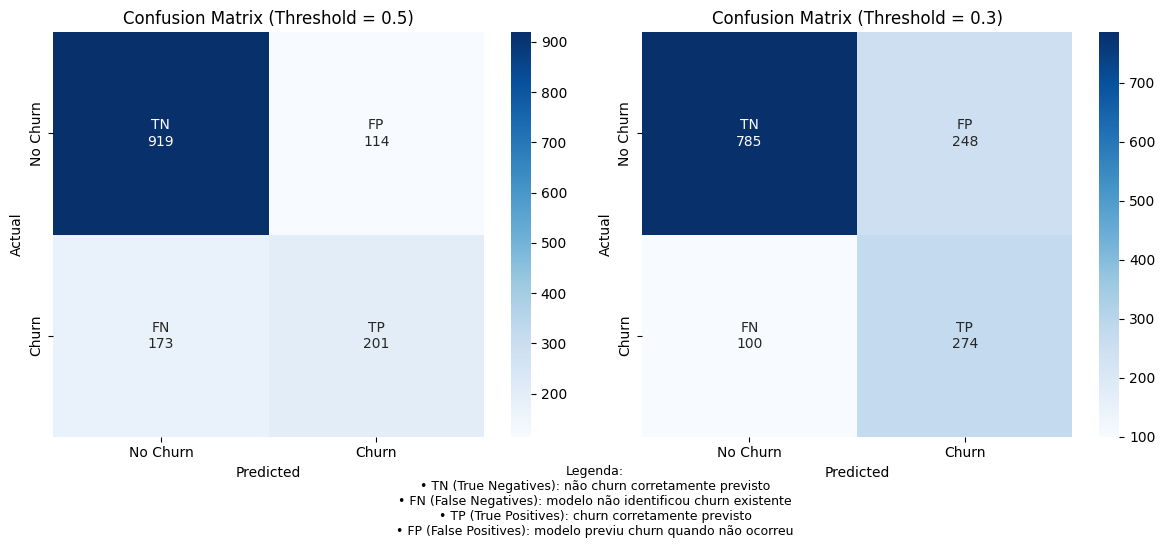

In [23]:
# threshold padrão
y_pred_05 = (probs >= 0.5).int().numpy()

# threshold ajustado
y_pred_03 = (probs >= 0.3).int().numpy()

cm_05 = confusion_matrix(y_true, y_pred_05)
cm_03 = confusion_matrix(y_true, y_pred_03)

def make_labels(cm):
    labels = [["TN", "FP"], ["FN", "TP"]]
    annot = []
    for i in range(2):
        row = []
        for j in range(2):
            row.append(f"{labels[i][j]}\n{cm[i][j]}")
        annot.append(row)
    return annot

annot_05 = make_labels(cm_05)
annot_03 = make_labels(cm_03)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_05,
    annot=annot_05,
    fmt="",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Threshold = 0.5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


sns.heatmap(
    cm_03,
    annot=annot_03,
    fmt="",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix (Threshold = 0.3)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

# legenda explicativa
plt.figtext(
    0.5, -0.08,
    "Legenda:\n"
    "• TN (True Negatives): não churn corretamente previsto\n"
    "• FN (False Negatives): modelo não identificou churn existente\n"
    "• TP (True Positives): churn corretamente previsto\n"
    "• FP (False Positives): modelo previu churn quando não ocorreu",
    ha="center",
    fontsize=9
)

plt.show()

### Comparação das matrizes de confusão para diferentes thresholds

Para avaliar o impacto do limiar de decisão do modelo, foram comparadas
as matrizes de confusão utilizando dois valores de threshold:

- **0.5 (valor padrão)**
- **0.3 (threshold reduzido)**

A comparação mostra mudanças importantes no comportamento do modelo.

Com o threshold **0.5**, o modelo apresenta maior precisão ao classificar
clientes que não irão cancelar o serviço, resultando em menos falsos
positivos. No entanto, uma quantidade maior de clientes que realmente
cancelaram não foi identificada, o que se reflete no número mais alto
de **False Negatives**.

Ao reduzir o threshold para **0.3**, o modelo se torna mais sensível à
detecção de churn. Isso aumenta o número de **True Positives**, permitindo
identificar mais clientes que realmente cancelam o serviço.

Por outro lado, essa maior sensibilidade também aumenta o número de
**False Positives**, ou seja, clientes que foram classificados como churn
mesmo sem cancelar o serviço.

Logo, dependendo do objetivo, o segundo modelo de 0,3 é mais adequado:
1) se a empresa quer evitar perder clientes, faz sentido o custo aceitável de ações em Falsos Positivos;
2) se a empresa quer evitar oferecer descontos desnecessários, o threshold 0,5 é melhor, mas entendemos que não seria o foco pensando em churn.

## Comparação com modelos baseline

Para avaliar o desempenho da rede neural (MLP), comparamos seus resultados
com modelos baseline amplamente utilizados em problemas de classificação:

- Logistic Regression (modelo linear)
- Random Forest (modelo baseado em árvores)

A comparação permite verificar se a rede neural realmente oferece ganhos
de desempenho em relação a modelos mais simples.

In [24]:
# Regressão Logística
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

roc_log = roc_auc_score(y_test, y_prob_log)

In [25]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

roc_rf = roc_auc_score(y_test, y_prob_rf)

### Comparação de desempenho entre modelos

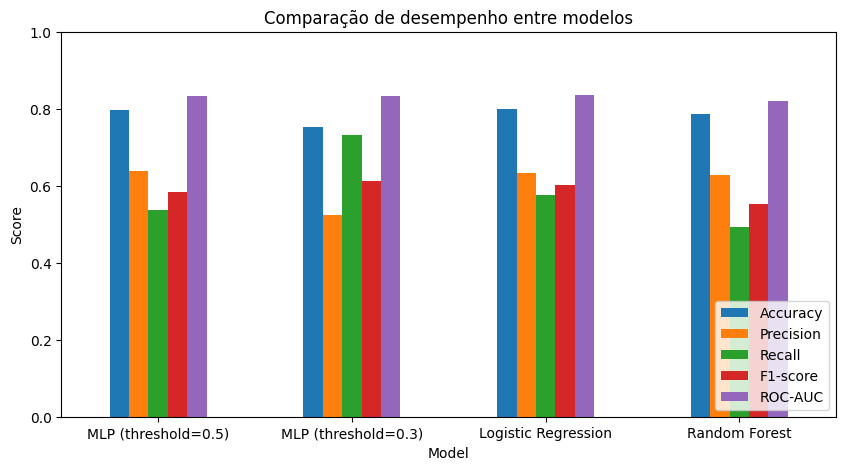

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,MLP (threshold=0.5),0.796,0.638,0.537,0.583,0.834
1,MLP (threshold=0.3),0.753,0.525,0.733,0.612,0.834
2,Logistic Regression,0.799,0.634,0.575,0.603,0.835
3,Random Forest,0.787,0.628,0.492,0.552,0.819


In [26]:
accuracy_mlp05 = accuracy_score(y_true, y_pred_05)
precision_mlp05 = precision_score(y_true, y_pred_05)
recall_mlp05 = recall_score(y_true, y_pred_05)
f1_mlp05 = f1_score(y_true, y_pred_05)

accuracy_mlp03 = accuracy_score(y_true, y_pred_03)
precision_mlp03 = precision_score(y_true, y_pred_03)
recall_mlp03 = recall_score(y_true, y_pred_03)
f1_mlp03 = f1_score(y_true, y_pred_03)


results = pd.DataFrame({
    "Model": [
        "MLP (threshold=0.5)",
        "MLP (threshold=0.3)",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_mlp05,
        accuracy_mlp03,
        accuracy_log,
        accuracy_rf
    ],
    "Precision": [
        precision_mlp05,
        precision_mlp03,
        precision_log,
        precision_rf
    ],
    "Recall": [
        recall_mlp05,
        recall_mlp03,
        recall_log,
        recall_rf
    ],
    "F1-score": [
        f1_mlp05,
        f1_mlp03,
        f1_log,
        f1_rf
    ],
    "ROC-AUC": [
        roc_mlp,
        roc_mlp,
        roc_log,
        roc_rf
    ]
})

# gráfico comparativo
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparação de desempenho entre modelos")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

# tabela formatada
results.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    color="#0000CC"
).format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
})

### Conclusão da comparação entre modelos baseline

A comparação entre os modelos mostra comportamentos distintos
dependendo da métrica analisada.

A **Logistic Regression** apresentou o melhor desempenho geral em
termos de **accuracy** e **ROC-AUC**, indicando boa capacidade de
separação entre clientes que cancelam e clientes que permanecem ativos.
Além disso, apresentou desempenho equilibrado entre precisão e recall,
resultando em um **F1-score competitivo**.

O modelo **MLP com threshold padrão (0.5)** apresentou desempenho
próximo ao da regressão logística, com valores similares de accuracy,
precision e ROC-AUC, demonstrando que o modelo neural também consegue
capturar padrões relevantes no conjunto de dados.

Entretanto, ao reduzir o threshold para **0.3**, o modelo MLP passou a
identificar uma proporção maior de clientes que realmente cancelam o
serviço, resultando no maior valor de **recall** entre os modelos.

Essa alteração também levou ao maior **F1-score**, indicando melhor
equilíbrio entre precisão e capacidade de detecção de churn. Esse
comportamento é esperado, pois thresholds menores tornam o modelo mais
sensível à classe positiva (cancelamento).

Já o **Random Forest** apresentou recall inferior em comparação aos
demais modelos, indicando menor capacidade de identificar clientes que
realmente cancelam o serviço.

Dessa forma, observa-se um trade-off entre desempenho geral e capacidade
de detecção de churn, sendo a escolha do modelo mais adequado dependente
do objetivo de negócio e do custo associado aos diferentes tipos de erro.

## Trade-off entre falsos positivos e falsos negativos

Em problemas de previsão de churn, é importante analisar o impacto
dos diferentes tipos de erro de classificação.

Dois erros são particularmente relevantes:

**False Positive (FP)**  
O modelo prevê que o cliente irá cancelar, mas ele permanece ativo.
Nesse caso, a empresa pode aplicar ações de retenção desnecessárias,
como ofertas ou descontos.

**False Negative (FN)**  
O modelo prevê que o cliente permanecerá, mas ele cancela o serviço.
Esse erro é geralmente mais crítico, pois representa a perda de um
cliente sem que ações preventivas tenham sido tomadas.

Para analisar esse trade-off, foram comparados dois thresholds
de decisão do modelo MLP: **0.5 (padrão)** e **0.3**.

A redução do threshold para **0.3** aumenta a sensibilidade do modelo,
resultando em:

- redução no número de **falsos negativos (FN)** (173 para 100)
- aumento no **recall**, indicando maior capacidade de identificar
  clientes com risco de churn  
- aumento no número de **falsos positivos (FP)** (114 para 248)

Esse comportamento é esperado, pois thresholds menores tornam o modelo
mais propenso a classificar clientes como churn.

Em muitos cenários de negócio, especialmente em estratégias de retenção,
é preferível aceitar um aumento moderado de falsos positivos para reduzir
a ocorrência de falsos negativos, uma vez que a perda de clientes tende
a gerar impactos financeiros maiores do que o custo de ações de retenção
aplicadas desnecessariamente.

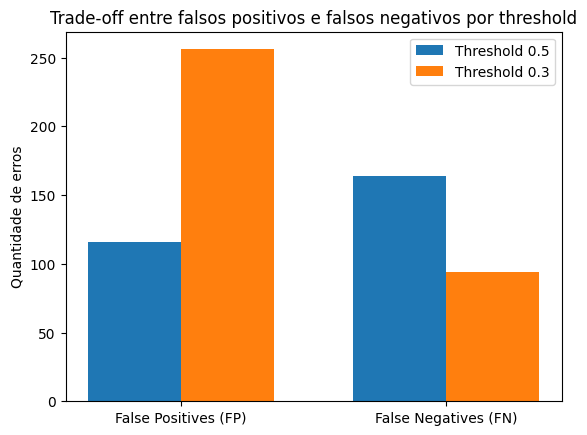

In [27]:
erros = ['False Positives (FP)', 'False Negatives (FN)']

t05 = [116, 164]
t03 = [256, 94]

x = np.arange(len(erros))
width = 0.35

plt.figure()

plt.bar(x - width/2, t05, width, label='Threshold 0.5')
plt.bar(x + width/2, t03, width, label='Threshold 0.3')

plt.xticks(x, erros)
plt.ylabel("Quantidade de erros")
plt.title("Trade-off entre falsos positivos e falsos negativos por threshold")

plt.legend()

plt.show()

O gráfico ilustra o impacto da alteração do threshold na distribuição
dos erros do modelo. A redução do threshold de 0.5 para 0.3 diminui
significativamente os falsos negativos, aumentando a capacidade de
identificar clientes com risco de churn (42% aumento), ao custo de um aumento nos
falsos positivos (120%).

### Registro de experimentos com MLflow

Todos os modelos treinados foram registrados utilizando MLflow,
permitindo o acompanhamento das métricas, parâmetros e versões
dos modelos avaliados durante o experimento.

2026/03/14 02:51:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 02:51:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/14 02:51:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 02:51:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

logistic_regression registrado no MLflow
random_forest registrado no MLflow
MLP registrado no MLflow
Todos os experimentos registrados com sucesso.


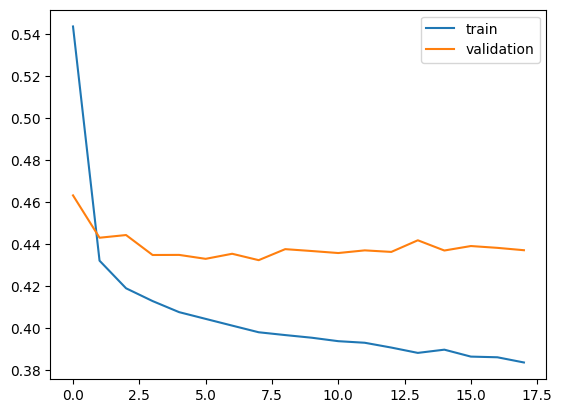

In [29]:
# -------------------------------------------------------------
# Registro de Experimentos no MLflow
# -------------------------------------------------------------

os.makedirs("../models", exist_ok=True)

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("telco_churn_baselines_etapa_02")


# -------------------------------------------------------------
# Função para modelos SKLEARN
# -------------------------------------------------------------

def log_model_mlflow(model, model_name, threshold=0.5):

    with mlflow.start_run(run_name=model_name):

        y_proba = model.predict_proba(X_test)[:,1]
        y_pred = (y_proba >= threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        mlflow.log_param("model", model_name)
        mlflow.log_param("threshold", threshold)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        mlflow.sklearn.log_model(model, "model")

        joblib.dump(model, f"../models/{model_name}.joblib")

        print(f"{model_name} registrado no MLflow")


# -------------------------------------------------------------
# Registrar modelos sklearn
# -------------------------------------------------------------

log_model_mlflow(log_model, "logistic_regression")
log_model_mlflow(rf_model, "random_forest")


# -------------------------------------------------------------
# Registrar MLP (PyTorch)
# -------------------------------------------------------------

with mlflow.start_run(run_name="mlp_model"):

    mlflow.log_param("model", "MLP_PyTorch")

    mlflow.log_metric("accuracy_threshold_05", accuracy_mlp05)
    mlflow.log_metric("precision_threshold_05", precision_mlp05)
    mlflow.log_metric("recall_threshold_05", recall_mlp05)
    mlflow.log_metric("f1_threshold_05", f1_mlp05)

    mlflow.log_metric("accuracy_threshold_03", accuracy_mlp03)
    mlflow.log_metric("precision_threshold_03", precision_mlp03)
    mlflow.log_metric("recall_threshold_03", recall_mlp03)
    mlflow.log_metric("f1_threshold_03", f1_mlp03)

    mlflow.log_metric("roc_auc", roc_mlp)

    # salvar modelo PyTorch
    torch.save(model.state_dict(), "../models/mlp_model.pt")
    mlflow.log_artifact("../models/mlp_model.pt")

    # salvar tabela comparativa
    results.to_csv("../models/model_results.csv", index=False)
    mlflow.log_artifact("../models/model_results.csv")

    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="validation")
    plt.legend()

    plt.savefig("../models/training_curve.png")

    mlflow.log_artifact("../models/training_curve.png")
    
    print("MLP registrado no MLflow")

print("Todos os experimentos registrados com sucesso.")

## Conclusão da Etapa 2

O modelo MLP treinado em PyTorch apresentou desempenho
comparável aos modelos tradicionais utilizados como baseline.

A análise mostrou que a escolha do threshold influencia
diretamente o trade-off entre precisão e recall, permitindo
ajustar o modelo conforme o custo de erro do problema de churn.

Todos os experimentos foram registrados no MLflow,
garantindo rastreabilidade e reprodutibilidade dos resultados.